# Wastewater viral loads

Covasim tracks each agent's viral load over time via a two-phase shedding model
controlled by `pars['viral_dist']` (`frac_time`, `load_ratio`, `high_cap`).
The full `pop_size × n_days` history matrix is stored in `sim.results['viral_load_hist']`.

This tutorial covers:

1. **Basic access** — inspecting the raw viral load matrix.
2. **Multi-variant wastewater signal** — simulating wild-type, AY.4, BA.2, and XBB.1.5
   introduced from consensus FASTA files, and plotting the per-variant infectious
   counts on both an absolute and a proportional y-axis using
   `sim.results['variant']['n_infectious_by_variant']`.
3. **Amplicon sequencing with Bygul** — at the first day where all four variants
   co-circulate, invoking Bygul's `simulate_proportions` CLI to produce synthetic
   ARTIC V4.1 amplicon reads that reflect the haplotype mixture proportions captured
   by `WastewaterSampler`.

Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM


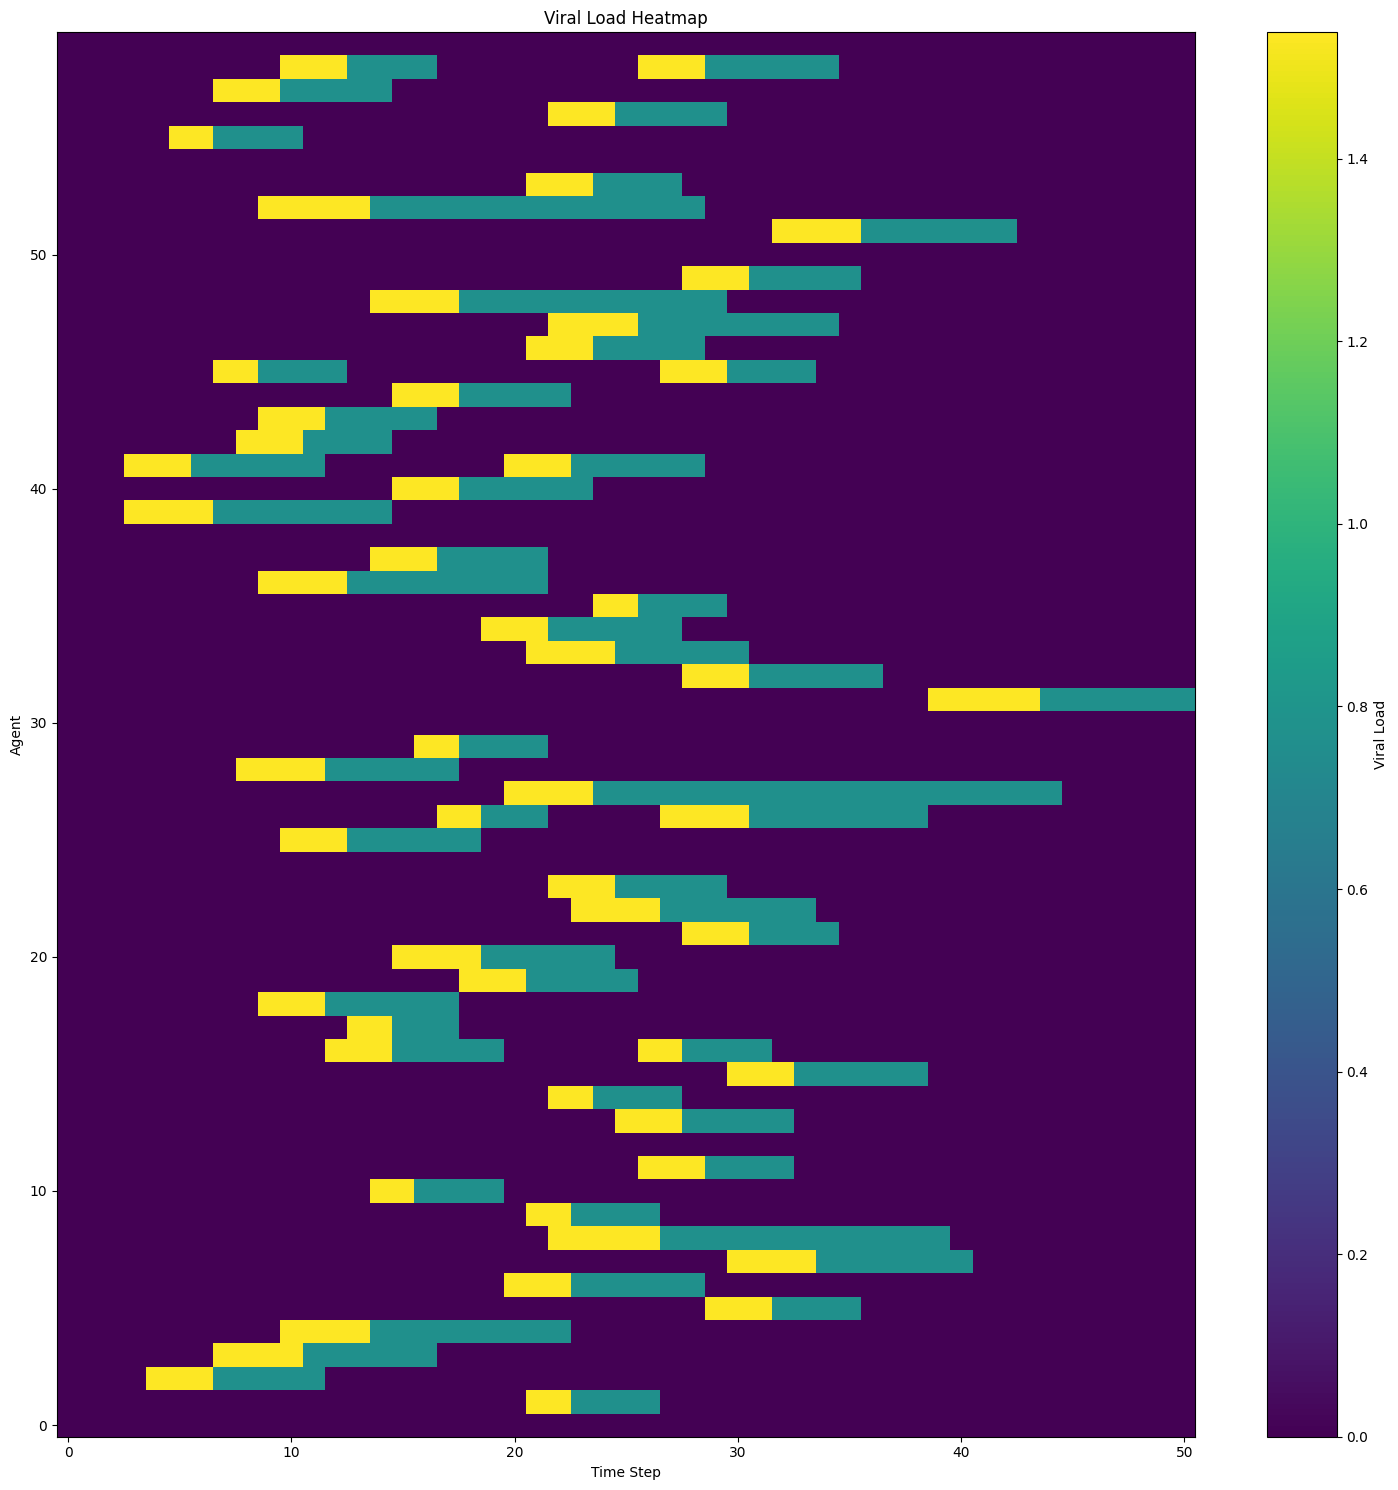

<Figure size 1200x600 with 0 Axes>

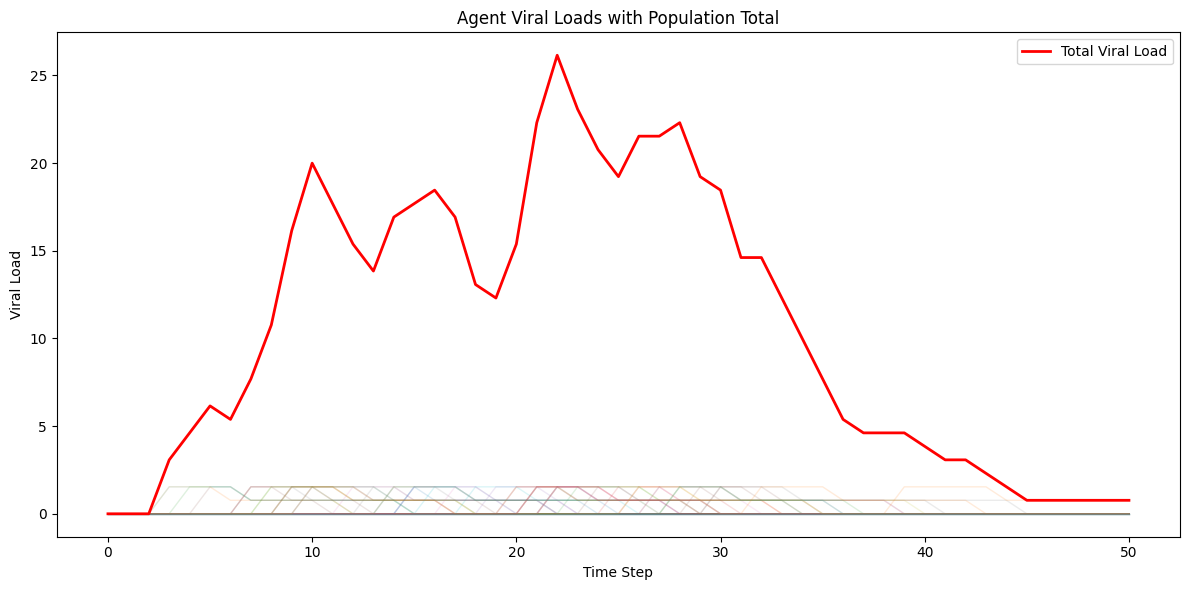

In [1]:
import covasim as cv
import matplotlib.pyplot as plt
import numpy as np

sim = cv.Sim(pop_size=60,
             pop_type='hybrid',
             pop_infected=3,
             location = "zambia",
             n_days=50,
             n_imports=0,
             verbose=0)
sim.run()
viral_load = sim.results['viral_load_hist']
plt.figure(figsize=(15, 15))

im = plt.imshow(
    viral_load,
    aspect='auto',      # prevents squashing
    origin='lower',     # agent 0 at bottom
    cmap='viridis'      # choose colormap
)

plt.colorbar(im, label='Viral Load')

plt.xlabel('Time Step')
plt.ylabel('Agent')
plt.title('Viral Load Heatmap')

plt.tight_layout()
plt.show()
plt.figure(figsize=(12,6))

sum_vl = viral_load.sum(axis=0)

plt.figure(figsize=(12,6))

# Individual agents
for i in range(viral_load.shape[0]):
    plt.plot(
        viral_load[i],
        alpha=0.15,
        linewidth=1
    )

# Population total
plt.plot(
    sum_vl,
    linewidth=2,
    color='red',
    label='Total Viral Load'
)

plt.xlabel('Time Step')
plt.ylabel('Viral Load')
plt.title('Agent Viral Loads with Population Total')
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
import covasim as cv

sim = cv.Sim(pop_size=2_000, pop_infected=5, n_days=60, verbose=0)
sim.run()

print('Viral load array shape:', sim.results['viral_load_hist'].shape,
      '  (rows = agents, columns = time-steps)')

Viral load array shape: (2000, 61)   (rows = agents, columns = time-steps)


## Multi-variant wastewater signal

We introduce three variants with `founding_fasta` files that set each variant's
characteristic mutation profile at the time of seeding.  Per-variant proportions
are read from `sim.results['variant']['n_infectious_by_variant']` — the standard Covasim
result tracking how many agents are infectious with each variant on every day.
`WastewaterSampler` is used only for haplotype-resolved data fed to Bygul (see
the next section).

> **Note:** FASTA files are in `sars-2-data/variants/` relative to this notebook.
> Run the notebook from the `docs/tutorials/` directory.

In [3]:
import covasim as cv
import numpy as np
import matplotlib.pyplot as plt

# Paths are relative to docs/tutorials/ — run the notebook from that directory.
ref_fasta         = 'sars-2-data/NC_045512_Hu-1.fasta'
fitness_data_path = '../../data/nt_fitness.csv'
ay4_fasta         = 'sars-2-data/variants/AY.4_consensus.fasta'
ba2_fasta         = 'sars-2-data/variants/BA.2_consensus.fasta'
xbb15_fasta       = 'sars-2-data/variants/XBB.1.5_consensus.fasta'
artic_primers     = 'sars-2-data/ARTIC_V4-1.bed'

# Variants — rel_beta is NOT hard-coded.  evo_pars (below) derives the
# transmission advantage from each variant's founding mutations by looking up
# every SNP in the Bloom lab nucleotide fitness landscape and computing
# rel_beta = exp(Σ log_fitness_i × fitness_scale).
ay4 = cv.variant(
    variant        = {},
    label          = 'AY.4',
    days           = 30,
    n_imports      = 50,
    founding_fasta = ay4_fasta,
)
ba2 = cv.variant(
    variant        = {},
    label          = 'BA.2',
    days           = 60,
    n_imports      = 50,
    founding_fasta = ba2_fasta,
)
xbb15 = cv.variant(
    variant        = {},
    label          = 'XBB.1.5',
    days           = 100,
    n_imports      = 50,
    founding_fasta = xbb15_fasta,
)

# WastewaterSampler captures each unique evolved haplotype so simulate_sample()
# can feed the mixture to Bygul for amplicon-read synthesis.
# Sampled after XBB.1.5's introduction (day 100) while all four variants are
# likely still co-circulating.
_haplotype_days = list(range(110, 151, 5))   # days 110, 115, 120 … 150
ww = cv.WastewaterSampler(
    days  = _haplotype_days,
    label = 'WastewaterHaplotype',
)

sim = cv.Sim(
    dict(
        pop_size     = 20_000,
        pop_infected = 20,
        start_day    = '2022-10-01',
        end_day      = '2023-04-01',
        evo_pars = dict(
            enable            = True,
            reference         = ref_fasta,
            mol_clock_rate    = 1e-6,
            fitness_model     = 'bloom_nt',           # Bloom lab nt_fitness.csv
            fitness_data_path = fitness_data_path,
            fitness_scale     = 0.05,                 # multiplies log-fitness sum before exp()
        ),
    ),
    variants  = [ay4, ba2, xbb15],
    analyzers = [ww],
    verbose   = 0,
)
sim.run()

/Users/dpilz/Desktop/covasim4wastewater/.venv/lib/python3.10/site-packages/covasim/sequence_evolution.py:104: UserWarning: founding_fasta "sars-2-data/variants/AY.4_consensus.fasta" length (29890) differs from reference (29903); aligning with biopython (indels ignored).
  warnings.warn(
/Users/dpilz/Desktop/covasim4wastewater/.venv/lib/python3.10/site-packages/covasim/sequence_evolution.py:104: UserWarning: founding_fasta "sars-2-data/variants/BA.2_consensus.fasta" length (29743) differs from reference (29903); aligning with biopython (indels ignored).
  warnings.warn(
/Users/dpilz/Desktop/covasim4wastewater/.venv/lib/python3.10/site-packages/covasim/sequence_evolution.py:104: UserWarning: founding_fasta "sars-2-data/variants/XBB.1.5_consensus.fasta" length (29749) differs from reference (29903); aligning with biopython (indels ignored).
  warnings.warn(


Sim(<no label>; 2022-10-01 to 2023-04-01; pop: 20000 random; epi: 58230⚙, 189☠)

In [4]:
# Show the rel_beta multiplier that was derived from each variant's founding mutations.
# This makes the FASTA → fitness → transmissibility pathway explicit.
tracker       = sim.people.sequence_tracker
fitness_model = tracker.fitness_model

print(f'{"variant":12s}  {"founding SNPs":>13s}  {"rel_beta (×wt)":>15s}')
print('-' * 46)
# Wild-type carries no founding mutations → reference fitness = 1.0
for label, muts in [('wild', frozenset())] + list(tracker.variant_founding_mutations.items()):
    mult = fitness_model.compute_fitness(muts)
    print(f'{label:12s}  {len(muts):>13d}  {mult:>15.4f}')

variant       founding SNPs   rel_beta (×wt)
----------------------------------------------
wild                      0           1.0000
AY.4                     43           1.7579
BA.2                     60           5.0353
XBB.1.5                  81          11.1664


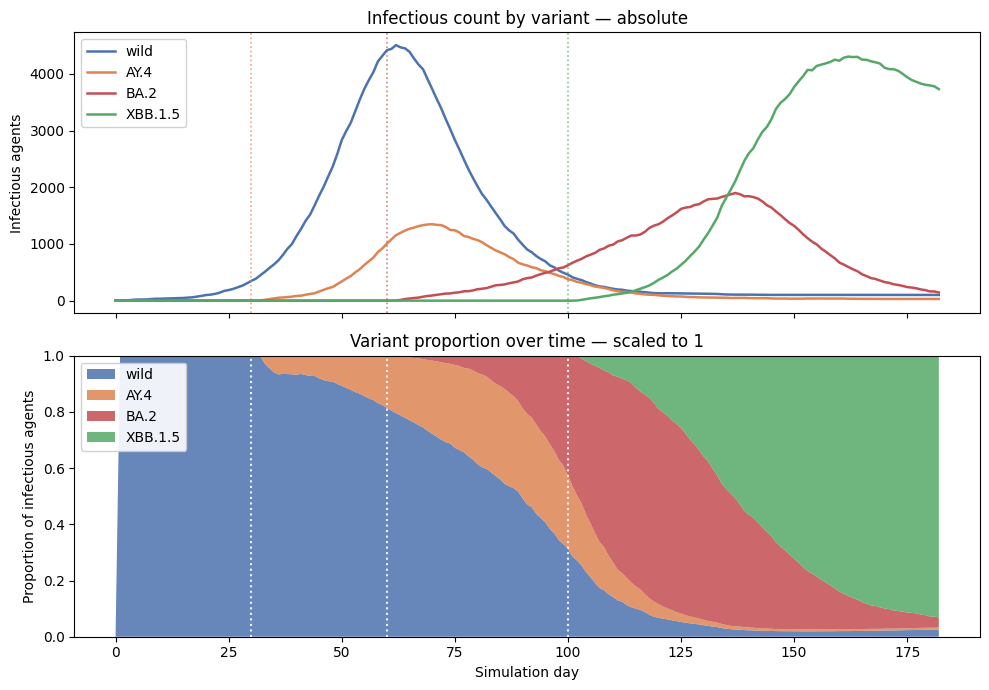

In [5]:
variant_names = list(sim['variant_map'].values())   # e.g. ['wild', 'AY.4', 'BA.2', 'XBB.1.5']
n_steps = sim.npts

# Per-variant infectious counts from the standard Covasim result.
# Shape: (n_variants, n_steps).
n_inf = np.array(sim.results['variant']['n_infectious_by_variant'].values)
total = n_inf.sum(axis=0)
total[total == 0] = 1  # avoid division by zero on days with no infections

loads = {v: n_inf[i] for i, v in enumerate(variant_names)}
props = {v: n_inf[i] / total for i, v in enumerate(variant_names)}

# Color palette (extend automatically for any extra variants)
palette = {'wild': '#4C72B0', 'AY.4': '#DD8452', 'BA.2': '#C44E52', 'XBB.1.5': '#55A868'}
_defaults = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, v in enumerate(variant_names):
    palette.setdefault(v, _defaults[i % len(_defaults)])

tvec       = np.arange(n_steps)
intro_days = {'AY.4': 30, 'BA.2': 60, 'XBB.1.5': 100}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# -- Absolute infectious counts -----------------------------------------------
for vname in variant_names:
    ax1.plot(tvec, loads[vname], label=vname, color=palette[vname], linewidth=1.8)
for vname, day in intro_days.items():
    ax1.axvline(day, color=palette[vname], linestyle=':', linewidth=1.2, alpha=0.7)
ax1.set_ylabel('Infectious agents')
ax1.set_title('Infectious count by variant — absolute')
ax1.legend(framealpha=0.9)

# -- Scaled to 1 (stacked area) -----------------------------------------------
stacked = np.array([props[v] for v in variant_names])
ax2.stackplot(tvec, stacked,
              labels=variant_names,
              colors=[palette[v] for v in variant_names],
              alpha=0.85)
for vname, day in intro_days.items():
    ax2.axvline(day, color='white', linestyle=':', linewidth=1.5, alpha=0.9)
ax2.set_xlabel('Simulation day')
ax2.set_ylabel('Proportion of infectious agents')
ax2.set_title('Variant proportion over time — scaled to 1')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

## Amplicon sequencing snapshot with Bygul

`WastewaterSampler` records every unique evolved haplotype present in the
infectious pool on each sampling day.  At a time-point where wild-type, AY.4,
BA.2, and XBB.1.5 all co-circulate the mixture mirrors what a real wastewater
sequencing lab would see.

`simulate_sample()` writes each haplotype to a temporary FASTA file and calls
[Bygul](https://github.com/andersen-lab/Bygul)'s `simulate_proportions` CLI,
which tiles ARTIC V4.1 amplicons across each genome and produces synthetic
paired-end reads at the observed mixture proportions — giving a realistic
amplicon-sequencing dataset that reflects the simulated epidemiology.

> **Requires** the `bygul` package: `pip install bygul`  
> BED file and reference FASTA are read from `sars-2-data/` via the paths
> set in the earlier cell (`artic_primers`, `ref_fasta`).

In [6]:
import glob, os, dataclasses

# From the candidate haplotype days, pick the first where all four variants
# each hold >1% of signal.  Fall back to day 120 if none qualifies.
ww = sim.get_analyzer('WastewaterHaplotype')
mixed_day = next(
    (t for t in sorted(ww.samples)
     if ww.samples[t] is not None
     and all(props[v][t] > 0.01 for v in ['wild', 'AY.4', 'BA.2', 'XBB.1.5'])),
    120,
)

print(f'Sampling day {mixed_day}  ({sim.date(mixed_day)})')
print('  Variant-level proportions at that day:')
for v in ['wild', 'AY.4', 'BA.2', 'XBB.1.5']:
    print(f'    {v:10s}  {props[v][mixed_day]:.1%}')

sample = ww.samples.get(mixed_day)
if sample is None:
    print('\nNo infectious agents were present on that day.')
else:
    print(f'\n  Unique haplotypes in pool : {sample.n_genotypes}')

    # Rank haplotypes by proportion and keep the top 5.
    # Renormalize so the subset proportions still sum to 1.0 — Bygul requires this.
    order     = sorted(range(sample.n_genotypes),
                       key=lambda i: sample.proportions[i], reverse=True)[:5]
    top_seqs  = [sample.sequences[i]   for i in order]
    top_loads = [sample.raw_loads[i]   for i in order]
    top_props = [sample.proportions[i] for i in order]
    top_total = sum(top_props)
    top_props = [p / top_total for p in top_props]
    top_props[-1] = 1.0 - sum(top_props[:-1])   # absorb floating-point residual

    print(f'  Top-5 proportions (renormalized): {[round(p, 4) for p in top_props]}')
    print(f'  These cover {top_total:.1%} of the full pool by viral shedding')

    # Replace the stored sample with the trimmed version so simulate_sample() sees it
    ww.samples[mixed_day] = dataclasses.replace(
        sample,
        sequences   = top_seqs,
        proportions = top_props,
        raw_loads   = top_loads,
        n_genotypes = len(top_seqs),
    )

# artic_primers and ref_fasta were set in the earlier cell
outdir = './amplicon_reads/'

try:
    ww.simulate_sample(
        day             = mixed_day,
        primers         = artic_primers,
        reference       = ref_fasta,
        outdir          = outdir,
        readcnt         = 300,
        redo            = True,
        simulation_mode = 'amplicon',
        seed            = 42,
    )
    fastq_files = (
        glob.glob(os.path.join(outdir, '**/*.fastq*'), recursive=True) +
        glob.glob(os.path.join(outdir, '*.fastq*'))
    )
    print(f'\nBygul wrote {len(fastq_files)} FASTQ file(s) to {outdir!r}:')
    for f in sorted(set(fastq_files))[:12]:
        print(f'  {os.path.relpath(f)}  ({os.path.getsize(f)/1024:.1f} kB)')
except ImportError as exc:
    print('\n[Bygul not installed — skipping read simulation]')
    print(str(exc))
    print('Install: pip install bygul   (https://github.com/andersen-lab/Bygul)')


Sampling day 110  (2023-01-19)
  Variant-level proportions at that day:
    wild        14.1%
    AY.4        12.3%
    BA.2        66.5%
    XBB.1.5     7.1%

  Unique haplotypes in pool : 415
  Top-5 proportions (renormalized): [0.6215, 0.1964, 0.0907, 0.0512, 0.0402]
  These cover 40.2% of the full pool by viral shedding
Directory './amplicon_reads/' exists. Removing andrecreating because --redo was set.

Genome: /var/folders/6f/j5htq5dj0jz5kmds0t7bf9fm0000gn/T/tmp70g_ac97/genotype_0.fasta
  Total ambiguous bases: 0
  Contig lengths:
    genotype_0: 29903

Genome: /var/folders/6f/j5htq5dj0jz5kmds0t7bf9fm0000gn/T/tmp70g_ac97/genotype_1.fasta
  Total ambiguous bases: 0
  Contig lengths:
    genotype_1: 29903

Genome: /var/folders/6f/j5htq5dj0jz5kmds0t7bf9fm0000gn/T/tmp70g_ac97/genotype_2.fasta
  Total ambiguous bases: 0
  Contig lengths:
    genotype_2: 29903

Genome: /var/folders/6f/j5htq5dj0jz5kmds0t7bf9fm0000gn/T/tmp70g_ac97/genotype_3.fasta
  Total ambiguous bases: 0
  Contig leng

Simulation progress...:   0%|          | 0/5 [00:00<?, ?it/s]

Processing sample genotype_0...
  Extracting ampliconsfrom contig: genotype_0...
No valid sequences for amplicon 75,no file written.please checkout the amplicon_stats.csv file for more information.
Starting read simulation...


Simulation progress...:  20%|██        | 1/5 [00:10<00:42, 10.64s/it]

Merging reads for genotype_0...
Processing sample genotype_1...
  Extracting ampliconsfrom contig: genotype_1...
Starting read simulation...


...

Merging reads for genotype_2...
Processing sample genotype_3...
  Extracting ampliconsfrom contig: genotype_3...
No valid sequences for amplicon 75,no file written.please checkout the amplicon_stats.csv file for more information.
Starting read simulation...


Simulation progress...:  80%|████████  | 4/5 [00:36<00:08,  8.98s/it]

Merging reads for genotype_3...
Processing sample genotype_4...
  Extracting ampliconsfrom contig: genotype_4...
No valid sequences for amplicon 75,no file written.please checkout the amplicon_stats.csv file for more information.
Starting read simulation...


Simulation progress...: 100%|██████████| 5/5 [00:45<00:00,  9.10s/it]

Merging reads for genotype_4...
Finished all samples!

Bygul wrote 1130 FASTQ file(s) to './amplicon_reads/':
  amplicon_reads/genotype_0/reads/amplicon_10_contig1_1.fastq  (15.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig1_2.fastq  (15.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig2_1.fastq  (15.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig2_2.fastq  (15.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig3_1.fastq  (15.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig3_2.fastq  (15.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig4_1.fastq  (15.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig4_2.fastq  (15.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_11_contig1_1.fastq  (60.8 kB)
  amplicon_reads/genotype_0/reads/amplicon_11_contig1_2.fastq  (60.8 kB)
  amplicon_reads/genotype_0/reads/amplicon_12_contig1_1.fastq  (60.8 kB)
  amplicon_reads/genotype_0/reads/amplicon_12_contig1_2.fastq  (60.8 kB)
